In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
def rnf(filepath): # function for reading and formatting dataframes from csv-like file
    df = pd.read_csv(filepath) #read in file
    df = df.map(lambda x: np.nan if x == -9999 else x) #convert -9999 to nan

    #Create column of datetime objects from the 'TIMESTAMP COLUMN'
    #Need to shift it 6 hours to put in local time (TIMESTAMP column is in UTC)
    df['dt_ts'] = pd.to_datetime(df['TIMESTAMP_START'], format = '%Y%m%d%H%M') - dt.timedelta(hours = 6)
    r = pd.date_range(start=dt.datetime(2025, 1, 1), end=df.dt_ts.max(), freq = '30min')
    df = df.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

    return(df)

In [8]:
pd.read_csv(base_dir + 'Server\\eddypro_KSA_full_output_2025-07-22T145331_adv.csv', header = 1, skiprows = [2])

,filename,date,time,DOY,daytime,file_records,used_records,Tau,qc_Tau,H,qc_H,LE,qc_LE,co2_flux,qc_co2_flux,h2o_flux,qc_h2o_flux,H_strg,LE_strg,co2_strg,h2o_strg,co2_v-adv,h2o_v-adv,co2_molar_density,co2_mole_fraction,co2_mixing_ratio,co2_time_lag,co2_def_timelag,h2o_molar_density,h2o_mole_fraction,h2o_mixing_ratio,h2o_time_lag,h2o_def_timelag,sonic_temperature,air_temperature,air_pressure,air_density,air_heat_capacity,air_molar_volume,ET,water_vapor_density,e,es,specific_humidity,RH,VPD,Tdew,u_unrot,v_unrot,w_unrot,u_rot,v_rot,w_rot,wind_speed,max_wind_speed,wind_dir,yaw,pitch,roll,u*,TKE,L,(z-d)/L,bowen_ratio,T*,model,x_peak,x_offset,x_10%,x_30%,x_50%,x_70%,x_90%,un_Tau,Tau_scf,un_H,H_scf,un_LE,LE_scf,un_co2_flux,co2_scf,un_h2o_flux,h2o_scf,spikes_hf,amplitude_resolution_hf,drop_out_hf,absolute_limits_hf,skewness_kurtosis_hf,skewness_kurtosis_sf,discontinuities_hf,discontinuities_sf,timelag_hf,timelag_sf,attack_angle_hf,non_steady_wind_hf,u_spikes,v_spikes,w_spikes,ts_spikes,co2_spikes,h2o_spikes,u_var,v_var,w_var,ts_var,co2_var,h2o_var,w/ts_cov,w/co2_cov,w/h2o_cov,fast_t_mean
0,agrivoltaics2_ts_data_2025_06_01_0000.dat,2025-06-01,00:30,152.020,0.0,18000.0,18000.0,0.032030,0.0,4.134024,1.0,17.458911,1.0,-0.395082,0.0,0.395320,1.0,-9999.000000,-9999.000000,-9999.000000,-9999.000000,68.596208,0.966155,15.923745,396.813260,399.043508,0.0,1.0,224.280723,5.588985,5.620397,0.0,1.0,294.473129,293.951680,98245.963703,1.161932,1008.578247,0.024920,0.025617,0.004042,548.268157,2449.336559,0.003478,22.384354,1901.068403,271.667639,-0.521946,-0.711545,-0.045496,0.883512,5.332008e-14,0.004308,0.883523,2.718820,126.261479,233.804255,-9999.0,-9999.0,0.166031,0.198748,-95.302819,-0.073450,0.236786,0.021247,1.0,22.390691,10.000000,19.000000,33.000000,54.000000,96.000000,267.000000,0.031231,1.025600,5.109360,1.018667,16.860390,1.022670,-0.726331,1.022670,0.381767,1.022670,899999999.0,800000099.0,800000099.0,800000199.0,800001099.0,800011099.0,899999999.0,899999999.0,89999.0,89999.0,89.0,89.0,8.0,4.0,2.0,17.0,5.0,1.0,0.190696,0.159917,0.046882,0.044387,0.000919,74.009361,0.004360,-0.000726,0.381767,19.947838
1,agrivoltaics2_ts_data_2025_06_01_0030.dat,2025-06-01,01:00,152.041,0.0,18000.0,18000.0,0.007505,0.0,-2.410434,1.0,8.577222,1.0,0.513061,0.0,0.194063,1.0,-4.691533,2.366650,0.430126,0.053546,-119.564174,-1.754777,16.049191,398.951655,401.301352,0.0,1.0,235.545134,5.855193,5.889679,0.0,1.0,293.697881,293.153070,98229.904464,1.164790,1008.701794,0.024858,0.012575,0.004245,574.240184,2331.511727,0.003644,24.629522,1757.271544,272.298716,-0.708335,-0.308456,-0.036497,0.773444,3.131752e-14,-0.007450,0.773479,1.761308,156.468476,203.620861,-9999.0,-9999.0,0.080271,0.079403,18.469470,0.379004,-0.281027,-0.025558,1.0,48.419643,21.000000,46.000000,99.000000,194.000000,447.000000,2209.000000,0.007434,1.009638,-1.865619,1.012224,8.428085,1.020391,0.537133,1.020391,0.190689,1.020391,899999999.0,800000099.0,800000099.0,800000199.0,800000099.0,800001099.0,899999999.0,899999999.0,89999.0,89999.0,89.0,89.0,8.0,4.0,2.0,17.0,5.0,1.0,0.071722,0.068227,0.018856,0.092148,0.002973,56.885650,-0.001588,0.000537,0.190689,18.836445
2,agrivoltaics2_ts_data_2025_06_01_0100.dat,2025-06-01,01:30,152.062,0.0,17987.0,17987.0,0.001172,2.0,3.359546,2.0,-0.571205,2.0,-1.340704,2.0,-0.012900,2.0,-11.319960,6.768595,2.770948,0.152859,242.972596,3.892362,16.703569,412.642107,415.387999,0.0,1.0,267.587140,6.610427,6.654416,0.0,1.0,291.849797,291.238703,98221.177940,1.172009,1009.063877,0.024704,-0.000836,0.004822,648.095355,2069.040269,0.004114,31.323477,1420.944914,273.964248,0.039955,0.494702,0.021381,0.496772,-1.528212e-14,0.014546,0.496985,1.363794,274.617513,85.388175,-9999.0,-9999.0,0.031621,0.123825,-0.810050,-8.641445,-5.881503,0.089838,1.0,25.996186,12.000000,20.000000,32.000000,48.000000,74.000000,156.000000,0.001125,1.041503,3.231181,1.029018,-0.661086,1.033162,-1.450226,1.033162,-0.014930,1.033162,899999999.0,800000099.0,800000099.0,800000199.0,800000099.0,801101199.

In [3]:
base_dir = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\EP_Output\\EP_settings_test\\'
ER = rnf(base_dir + 'ExpressRun\\eddypro_KSC_fluxnet_2025-07-01T093141_exp.csv')
PF = rnf(base_dir + 'AdvSet_PlanarFit\\eddypro_KSC_fluxnet_2025-07-01T181845_adv.csv')
PF_NW = rnf(base_dir + 'AdvSet_PlanarFit_No_w_bias\\eddypro_KSC_fluxnet_2025-07-02T135313_adv.csv')
EP_serv = rnf(base_dir + 'Server\\eddypro_KSA_essentials_2025-07-22T145331_adv.csv')


KSC_DL = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_flux.csv')
dtts_KSC = pd.to_datetime(KSC_DL.TIMESTAMP, format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6) - dt.timedelta(minutes = 30) #datetime timestamp for control tower data
KSC_DL.set_index(dtts_KSC, inplace = True)


#Create column of datetime objects from the 'TIMESTAMP COLUMN'
#Need to shift it 6 hours to put in local time (TIMESTAMP column is in UTC)


KeyError: 'TIMESTAMP_START'

Text(0.5, 1.0, 'planar fit - planar fit no w bias')

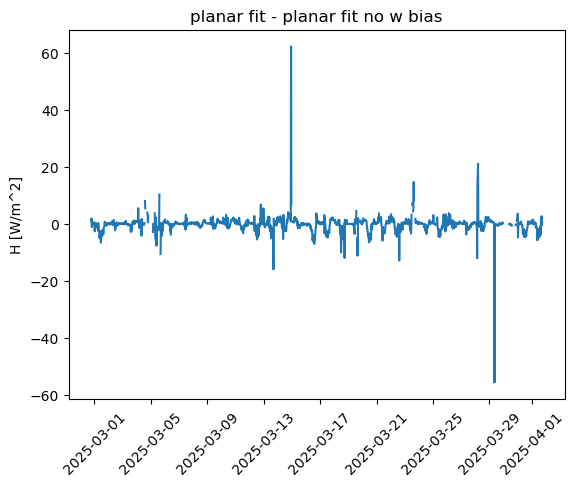

In [ ]:
var = 'H'
# plt.plot(ER[var])
# plt.plot(PF[var])
# plt.plot(PF_NW[var])
plt.plot(PF[var] - PF_NW[var])
plt.xticks(rotation = 45);
plt.ylabel('H [W/m^2]')
plt.title('planar fit - planar fit no w bias')

mean =  0.03606534656417929
RMSD =  2.421141257562904


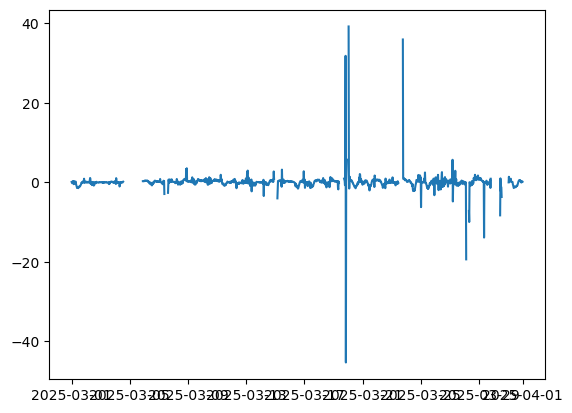

In [91]:
startdate = dt.datetime(2025, 3, 1)
enddate = dt.datetime(2025, 4, 1)

diff = PF[startdate:enddate]['FC'] - KSC_DL[startdate:enddate]['Fc_wpl']*1000/44
diff = diff.where((diff<100) & (diff>-100))
plt.plot(diff)
print('mean = ', diff.mean())

print('RMSD = ',  ((diff**2).mean())**(1/2))

(-10.0, 10.0)

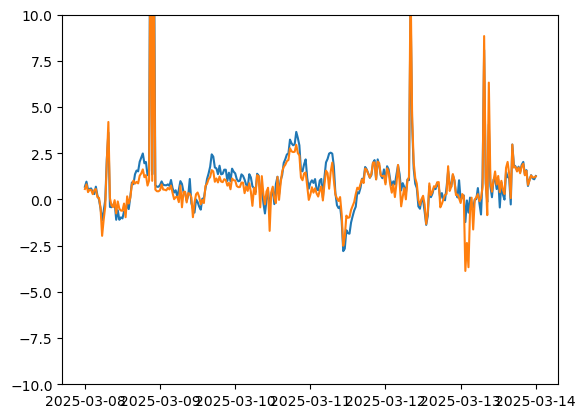

In [92]:
startdate = dt.datetime(2025, 3, 8)
enddate = dt.datetime(2025, 3, 14)
plt.plot(PF[startdate:enddate]['FC'])
plt.plot(KSC_DL[startdate:enddate]['Fc_wpl']*1000/44)
plt.ylim(-10, 10)

In [43]:
KSC_DL.columns

Index(['Unnamed: 0', 'TIMESTAMP', 'RECORD', 'Hs', 'tau', 'u_star', 'Ts_stdev',
       'Ts_Ux_cov', 'Ts_Uy_cov', 'Ts_Uz_cov', 'Ux_stdev', 'Ux_Uy_cov',
       'Ux_Uz_cov', 'Uy_stdev', 'Uy_Uz_cov', 'Uz_stdev', 'wnd_spd',
       'rslt_wnd_spd', 'wnd_dir_sonic', 'std_wnd_dir', 'wnd_dir_compass',
       'Ux_Avg', 'Uy_Avg', 'Uz_Avg', 'Ts_Avg', 'sonic_azimuth',
       'sonic_samples_Tot', 'diag_sonic_aggregate', 'no_sonic_head_Tot',
       'no_new_sonic_data_Tot', 'sonic_amp_l_f_Tot', 'sonic_amp_h_f_Tot',
       'sonic_sig_lck_f_Tot', 'sonic_del_T_f_Tot', 'sonic_aq_sig_f_Tot',
       'sonic_cal_err_f_Tot', 'Fc_wpl', 'LE_wpl', 'Hc', 'CO2_stdev',
       'CO2_Ux_cov', 'CO2_Uy_cov', 'CO2_Uz_cov', 'H2O_stdev', 'H2O_Ux_cov',
       'H2O_Uy_cov', 'H2O_Uz_cov', 'Tc_stdev', 'Tc_Ux_cov', 'Tc_Uy_cov',
       'Tc_Uz_cov', 'CO2_mean', 'H2O_mean', 'amb_tmpr_Avg', 'amb_press_mean',
       'Tc_mean', 'rho_a_mean', 'Fc_irga', 'LE_irga', 'CO2_wpl_LE',
       'CO2_wpl_H', 'H2O_wpl_LE', 'H2O_wpl_H', 'irga_samples